# The full bracketlearn zoo: exhaustive leaderboard

Every applicable trainer × wrapper combination from `bracketlearn`,
benchmarked on California housing with a separate time-series mini section on
bike-sharing demand. Both targets are continuous underlyings modelled as
distributions and priced on bracket ladders; see the housing and bike
notebooks for that framing. Here the focus is breadth and ranking.

Categories covered:

1. **Baselines**: `EmpiricalDistribution`, `Persistence` variants.
2. **Native dist trainers**: `EMOS`, `NGBoostNormal`, `MixtureNormals`,
   `QuantileReg`, `QuantileForest`, `CumulativeBinary`.
3. **Point + lifter combos**: sklearn regressors lifted via `GlobalResidual`,
   `StudentTResidual`, `GARCHResidual`.
4. **Calibrated wrappers**: `Isotonic`, `ConformalCalibrate`.
5. **Multi-stage DAGs**: `StackedParametric`, `DistAsFeatures`,
   `LinearPoolDist`, `CDFBoostBracket`, `TailSpecialist` over a shared
   upstream set.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "_src"))

import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Lasso, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_predict

warnings.filterwarnings(
    "ignore", message="X does not have valid feature names.*",
    category=UserWarning,
)

import matplotlib.pyplot as plt
from _style import (
    FAMILY_COLORS,
    color_for,
    leaderboard_bar,
)
from bracketlearn.baselines import EmpiricalDistribution
from bracketlearn.compose import Stacker, WalkForward
from bracketlearn.lift import ConformalCalibrate, GlobalResidual, Isotonic, StudentTResidual
from bracketlearn.pipeline import Pipeline
from bracketlearn.score import to_point
from bracketlearn.trainers import (
    EMOS,
    CDFBoostBracket,
    CumulativeBinary,
    DistAsFeatures,
    LinearPoolDist,
    MixtureNormals,
    NGBoostNormal,
    QuantileForest,
    QuantileReg,
    SklearnPoint,
    StackedParametric,
)
from lightgbm import LGBMRegressor

## Dataset 1 — California housing

In [2]:
data = fetch_california_housing()
X_raw = np.asarray(data.data, dtype=float)
y = np.asarray(data.target, dtype=float)
rng = np.random.default_rng(0)
keep = rng.choice(X_raw.shape[0], size=4000, replace=False)
X_raw, y = X_raw[keep], y[keep]
ids = np.arange(y.shape[0])
ts = ids.astype(float)
print(f"X shape: {X_raw.shape}  y in [${y.min()*100:.0f}k, ${y.max()*100:.0f}k]  "
      f"std=${y.std()*100:.0f}k")

# Synthetic ensemble for trainers that expect rows-by-experts (EMOS,
# MixtureNormals). Three weakly-correlated "vendor" forecasts produced
# by OOF predictions of cheap regressors.
ridge_oof = cross_val_predict(RidgeCV(), X_raw, y, cv=5)
lgb_oof = cross_val_predict(
    LGBMRegressor(n_estimators=200, learning_rate=0.05,
                  verbose=-1, random_state=0),
    X_raw, y, cv=5,
)
lin_oof = cross_val_predict(LinearRegression(), X_raw, y, cv=5)
X_ens = np.column_stack([ridge_oof, lgb_oof, lin_oof]).astype(float)
print(f"ensemble-style X: shape {X_ens.shape}  "
      f"(synthesised from RidgeCV / LightGBM / LinearRegression)")

X shape: (4000, 8)  y in [$18k, $500k]  std=$115k


ensemble-style X: shape (4000, 3)  (synthesised from RidgeCV / LightGBM / LinearRegression)


Bracket ladder with outer bins going to 0 / $1M so qreg's clipped tails
don't bleed mass.

In [3]:
edges = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 10.0])
cutpoints = edges[1:-1]   # for CumulativeBinary
# CumulativeBinary takes per-row grids at call time; one shared grid here → map
# every row id to the same interior cutpoints and outer-edge pair, and pass them
# to fit_predict below (WalkForward forwards them; non-bracket trainers drop them).
_cum_cuts = {int(i): cutpoints for i in ids}
_cum_outer = {int(i): (float(edges[0]), float(edges[-1])) for i in ids}

## Single-stage trainers

Family tag (used for colour-coding in the final bar chart): one of
`baseline`, `native_dist`, `point_lift`, `calibrated`, `bracket`.

In [4]:
SINGLE_TRAINERS = {
    # name                              : (forecaster, X_in, family)
    "Empirical":                          (EmpiricalDistribution(),       X_raw, "baseline"),
    "NGBoost":                            (NGBoostNormal(n_estimators=200, random_seed=0), X_raw, "native_dist"),
    "QuantileReg":                        (QuantileReg(n_estimators=200, learning_rate=0.05, random_seed=0), X_raw, "native_dist"),
    "QuantileForest":                     (QuantileForest(n_estimators=200, random_seed=0), X_raw, "native_dist"),
    "CumulativeBinary":                   (CumulativeBinary(n_estimators=80), X_raw, "bracket"),
    "EMOS  (ens. X)":                     (EMOS(), X_ens, "native_dist"),
    "MixtureNormals (ens. X)":            (MixtureNormals(), X_ens, "native_dist"),
    "Ridge + GlobalResidual":             (Pipeline([SklearnPoint(RidgeCV()), GlobalResidual()], name="ridge_gr"), X_raw, "point_lift"),
    "Lasso + GlobalResidual":             (Pipeline([SklearnPoint(Lasso(alpha=0.01)), GlobalResidual()], name="lasso_gr"), X_raw, "point_lift"),
    "LGBM + GlobalResidual":              (Pipeline([SklearnPoint(LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                                                                verbose=-1, random_state=0)),
                                                     GlobalResidual()], name="lgb_gr"), X_raw, "point_lift"),
    "Ridge + StudentTResidual":           (Pipeline([SklearnPoint(RidgeCV()), StudentTResidual()], name="ridge_t"), X_raw, "point_lift"),
    "EMOS + Isotonic (ens. X)":           (Pipeline([EMOS(), Isotonic(pre_integrate_edges=edges)], name="emos_iso"), X_ens, "calibrated"),
    "QReg + Conformal":                   (Pipeline([QuantileReg(n_estimators=200, learning_rate=0.05, random_seed=0),
                                                     ConformalCalibrate()], name="qreg_conf"), X_raw, "calibrated"),
}

In [5]:
def _score_one(stage_name, forecaster, X_in):
    model = forecaster if isinstance(forecaster, Pipeline) else Pipeline([forecaster], name=stage_name)
    key = model.name
    r = WalkForward(
        cv="kfold", n_folds=5, shuffle=True, random_state=0, refit_on_full=False,
    ).fit_predict(model, X_in, y, ids=ids, timestamps=ts,
                  cutpoints_by_id=_cum_cuts, outer_edges_by_id=_cum_outer)
    metrics = r.score(y, metrics=["crps", "log_score"])[key]
    dist = r[key]
    y_oof = y[dist.ids.astype(int)]
    mu = to_point(dist, how="mean")
    return {
        "CRPS":      float(metrics["crps"]),
        "log_score": float(metrics["log_score"]),
        "RMSE":      float(np.sqrt(mean_squared_error(y_oof, mu))),
        "MAE":       float(mean_absolute_error(y_oof, mu)),
    }


print("fitting single-stage trainers …")
single_results = {}
families: dict[str, str] = {}
for name, (fc, X_in, fam) in SINGLE_TRAINERS.items():
    try:
        single_results[name] = _score_one(
            name.split()[0].lower().replace("+", "_"), fc, X_in,
        )
        families[name] = fam
        m = single_results[name]
        print(f"  [{fam:11}] {name:<28}  CRPS={m['CRPS']:7.3f}  "
              f"log_score={m['log_score']:7.3f}  RMSE={m['RMSE']:6.3f}")
    except Exception as exc:
        print(f"  {name:<28}  FAILED: {exc!r}")

fitting single-stage trainers …
  [baseline   ] Empirical                     CRPS=  0.612  log_score=  1.375  RMSE= 1.147


  [native_dist] NGBoost                       CRPS=  0.344  log_score=  0.926  RMSE= 0.646


  [native_dist] QuantileReg                   CRPS=  0.251  log_score= -0.401  RMSE= 0.543


  [native_dist] QuantileForest                CRPS=  0.272  log_score= -0.370  RMSE= 0.580


  [bracket    ] CumulativeBinary              CRPS=  0.392  log_score=  1.606  RMSE= 0.687
  [native_dist] EMOS  (ens. X)                CRPS=  0.532  log_score=  1.309  RMSE= 2.118


  [native_dist] MixtureNormals (ens. X)       CRPS=  0.487  log_score=  1.220  RMSE= 1.899
  [point_lift ] Ridge + GlobalResidual        CRPS=  0.405  log_score=  2.532  RMSE= 1.425
  [point_lift ] Lasso + GlobalResidual        CRPS=  0.407  log_score=  2.563  RMSE= 1.434


  [point_lift ] LGBM + GlobalResidual         CRPS=  0.267  log_score=  0.757  RMSE= 0.513
  Ridge + StudentTResidual      FAILED: NotImplementedError('StudentTForecast.crps not implemented — no closed-form CRPS for Student-t in score.py yet. Use MC via sample().')


  [calibrated ] EMOS + Isotonic (ens. X)      CRPS=  0.511  log_score=  3.547  RMSE= 0.936


  [calibrated ] QReg + Conformal              CRPS=  0.251  log_score= -0.517  RMSE= 0.543


## Multi-stage DAGs

Trainers that consume *upstream* distributions positionally via `Stacker`.

In [6]:
print("fitting multi-stage DAGs …")
multistage_results = {}

# Base nodes are shared OBJECTS; each meta is a Stacker over them. WalkForward
# dedups by identity, so ridge/ngboost/qreg are each fit once per fold.
ridge = Pipeline([SklearnPoint(RidgeCV()), GlobalResidual()], name="ridge")
ngboost = Pipeline([NGBoostNormal(n_estimators=150, random_seed=0)], name="ngboost")
qreg = Pipeline(
    [QuantileReg(n_estimators=150, learning_rate=0.05, random_seed=0)], name="qreg",
)
stack = Stacker([ridge, ngboost], StackedParametric(), name="stack")
daf_lgb = Stacker(
    [ridge, ngboost, qreg],
    DistAsFeatures(
        downstream=NGBoostNormal(n_estimators=100, random_seed=0),
        include_variance=False,
    ),
    name="daf_lgb",
)
pool = Stacker([ridge, ngboost, qreg], LinearPoolDist(), name="pool")
cdfboost = Stacker(
    [ridge, ngboost, qreg],
    CDFBoostBracket(
        brackets_by_id={int(i): edges for i in ids},
        n_estimators=80, learning_rate=0.05,
    ),
    name="cdfboost",
)
dag_result = WalkForward(
    cv="kfold", n_folds=5, shuffle=True, random_state=0, refit_on_full=False,
).fit_predict([stack, daf_lgb, pool, cdfboost], X_raw, y, ids=ids, timestamps=ts)
for stage in ["stack", "daf_lgb", "pool", "cdfboost"]:
    dist = dag_result[stage]
    metrics = dag_result.score(y, metrics=["crps", "log_score"])[stage]
    y_oof = y[dist.ids.astype(int)]
    try:
        mu = to_point(dist, how="mean")
        rmse = float(np.sqrt(mean_squared_error(y_oof, mu)))
        mae = float(mean_absolute_error(y_oof, mu))
    except Exception:
        rmse = mae = float("nan")
    label = {
        "stack":    "StackedParametric (ridge,ngb)",
        "daf_lgb":  "DistAsFeatures→NGBoost",
        "pool":     "LinearPoolDist",
        "cdfboost": "CDFBoostBracket",
    }[stage]
    multistage_results[label] = {
        "CRPS":      float(metrics["crps"]),
        "log_score": float(metrics["log_score"]),
        "RMSE":      rmse,
        "MAE":       mae,
    }
    families[label] = "multistage"
    print(f"  [multistage] {label:<32}  CRPS={metrics['crps']:7.3f}  "
          f"log_score={metrics['log_score']:7.3f}")

fitting multi-stage DAGs …


  [multistage] StackedParametric (ridge,ngb)     CRPS=  0.342  log_score=  1.048
  [multistage] DistAsFeatures→NGBoost            CRPS=  0.293  log_score=  0.812
  [multistage] LinearPoolDist                    CRPS=  0.265  log_score= -2.935
  [multistage] CDFBoostBracket                   CRPS=  0.291  log_score=  0.737


## Combined leaderboard

In [7]:
all_results = {**single_results, **multistage_results}
base_crps = all_results["Empirical"]["CRPS"]
rows = sorted(all_results.items(), key=lambda kv: kv[1]["CRPS"])

print(f"\n{'rank':<5}{'family':<13}{'model':<34}{'CRPS':>9}{'log_score':>11}"
      f"{'RMSE':>8}{'MAE':>8}{'CRPSS':>8}")
print("-" * 96)
for i, (name, m) in enumerate(rows, 1):
    skill = 1 - m["CRPS"] / base_crps
    fam = families.get(name, "")
    print(f"{i:<5}{fam:<13}{name:<34}{m['CRPS']:>9.3f}{m['log_score']:>11.3f}"
          f"{m['RMSE']:>8.3f}{m['MAE']:>8.3f}{skill:>+8.3f}")


rank family       model                                  CRPS  log_score    RMSE     MAE   CRPSS
------------------------------------------------------------------------------------------------
1    calibrated   QReg + Conformal                      0.251     -0.517   0.543   0.370  +0.589
2    native_dist  QuantileReg                           0.251     -0.401   0.543   0.370  +0.589
3    multistage   LinearPoolDist                        0.265     -2.935   0.553   0.380  +0.568
4    point_lift   LGBM + GlobalResidual                 0.267      0.757   0.513   0.344  +0.563
5    native_dist  QuantileForest                        0.272     -0.370   0.580   0.398  +0.555
6    multistage   CDFBoostBracket                       0.291      0.737   0.626   0.429  +0.525
7    multistage   DistAsFeatures→NGBoost                0.293      0.812   0.554   0.392  +0.521
8    multistage   StackedParametric (ridge,ngb)         0.342      1.048   0.681   0.461  +0.441
9    native_dist  NGBoost    

## Family-coloured leaderboard

Sorted within family then by skill. Family colours match the rest of
the notebook series.

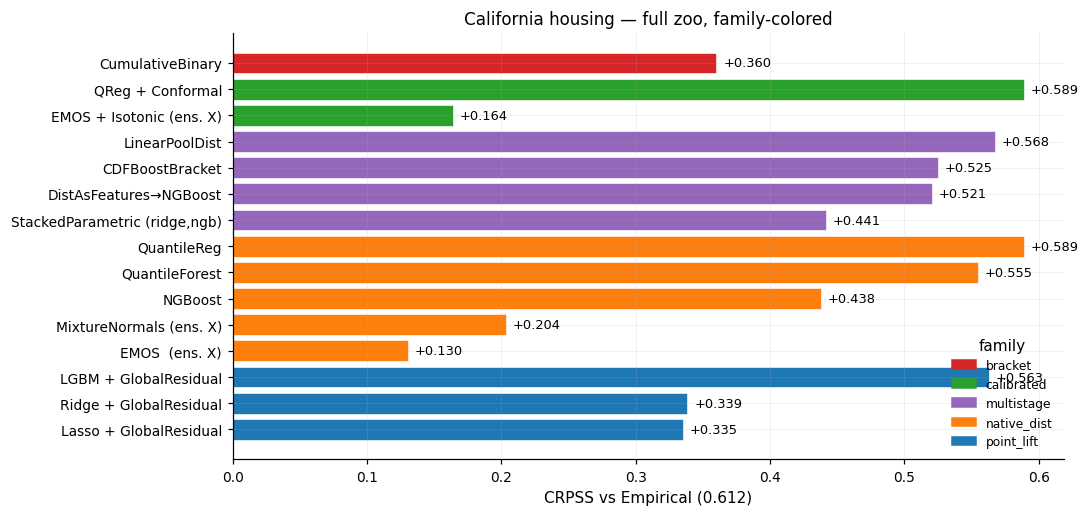

In [8]:
fig = leaderboard_bar(
    [(name, m["CRPS"]) for name, m in rows],
    baseline_name="Empirical", baseline_value=base_crps,
    skill_label="CRPSS",
    families=families,
    title="California housing — full zoo, family-colored",
)
plt.show()

## Distributional vs point — do the rankings agree?

Per-model scatter of CRPS skill vs RMSE skill (both vs Empirical).
Models on the diagonal rank the same way under both lenses; off-
diagonal points are the *interesting* ones — a model that beats
baseline on CRPS but ties on RMSE has captured the **spread** rather
than improved the **mean**, and that's exactly what bracket
contracts pay for.

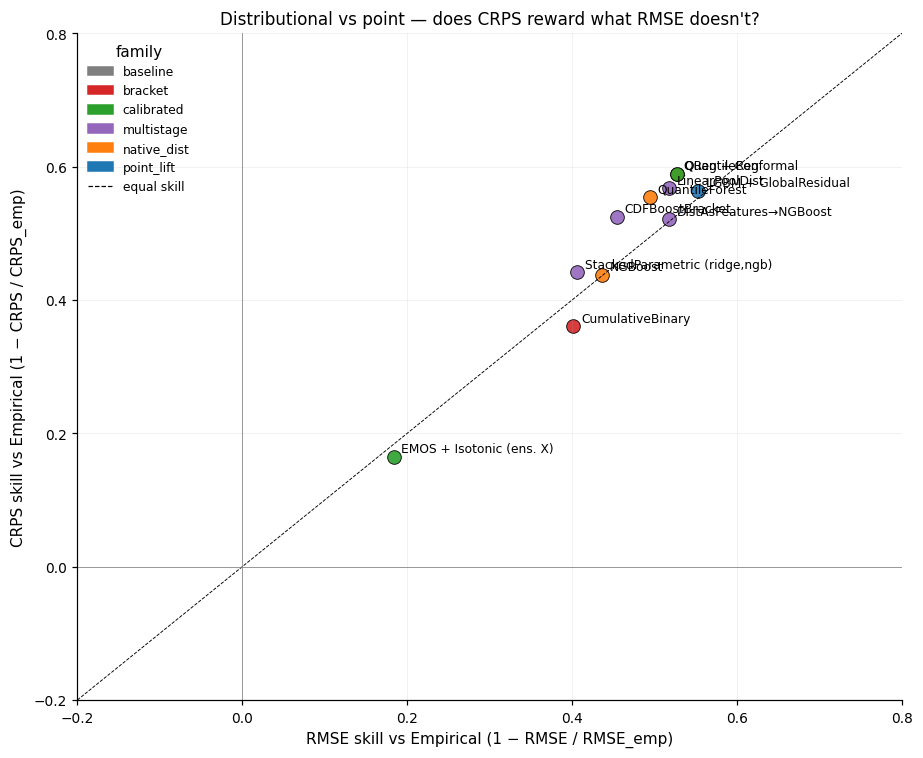

In [9]:
base_rmse = all_results["Empirical"]["RMSE"]

fig, ax = plt.subplots(figsize=(8.5, 7))
for name, m in all_results.items():
    if name == "Empirical":
        continue
    crps_skill = 1 - m["CRPS"] / base_crps
    rmse_skill = 1 - m["RMSE"] / base_rmse
    fam = families.get(name, "")
    c = FAMILY_COLORS.get(fam, color_for(name))
    ax.scatter(rmse_skill, crps_skill, s=80, color=c,
               edgecolor="black", linewidth=0.6, alpha=0.9)
    ax.annotate(name, (rmse_skill, crps_skill), fontsize=8,
                xytext=(5, 3), textcoords="offset points")
mn, mx = -0.2, 0.8
ax.plot([mn, mx], [mn, mx], "k--", lw=0.6, label="equal skill")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)
ax.set_xlabel("RMSE skill vs Empirical (1 − RMSE / RMSE_emp)")
ax.set_ylabel("CRPS skill vs Empirical (1 − CRPS / CRPS_emp)")
ax.set_title("Distributional vs point — does CRPS reward what RMSE doesn't?")
# Build the family legend.
present = sorted({f for f in families.values()})
handles = [plt.Rectangle((0, 0), 1, 1, color=FAMILY_COLORS.get(f, "gray"))
           for f in present]
ax.legend([*handles, plt.Line2D([0], [0], color="black", linestyle="--", lw=0.8)],
          [*present, "equal skill"],
          loc="upper left", title="family", fontsize=8)
fig.tight_layout()
plt.show()

## Dataset 2 — Bike-sharing mini

Persistence lags + learned models, under expanding-window CV.

In [10]:
import pandas as pd
from bracketlearn.baselines import Persistence
from sklearn.datasets import fetch_openml

print("loading Bike_Sharing_Demand …")
ds = fetch_openml("Bike_Sharing_Demand", version=2,
                  as_frame=True, parser="pandas")
df = ds.data.copy()
y_b_raw = ds.target.to_numpy(dtype=float)
df = df.sort_values(["year", "month", "hour"]).reset_index(drop=True)
y_b = y_b_raw[df.index.to_numpy()]
cat_cols = [c for c in df.columns if str(df[c].dtype) == "category"]
num_cols = [c for c in df.columns if c not in cat_cols]
dummies = pd.get_dummies(df[cat_cols], drop_first=True).astype(float)
X_b = pd.concat([df[num_cols].astype(float), dummies], axis=1).to_numpy(dtype=float)
n_b = X_b.shape[0]
ids_b = np.arange(n_b)
ts_b = ids_b.astype(float)
print(f"  rows={n_b}  features={X_b.shape[1]}  y in [{y_b.min():.0f}, {y_b.max():.0f}]")

loading Bike_Sharing_Demand …


  rows=17379  features=16  y in [1, 977]


fitting bike-sharing pipeline …



model               CRPS   log_score    vs emp   vs P-24
--------------------------------------------------------
qreg              100.33        6.01    +0.064    +0.134
ngboost           103.78        6.80    +0.032    +0.104
emp               107.17        6.19    +0.000    +0.075
persist168        112.33        6.75    -0.048    +0.031
persist24         115.88        6.76    -0.081    +0.000
persist1          187.94        7.74    -0.754    -0.622


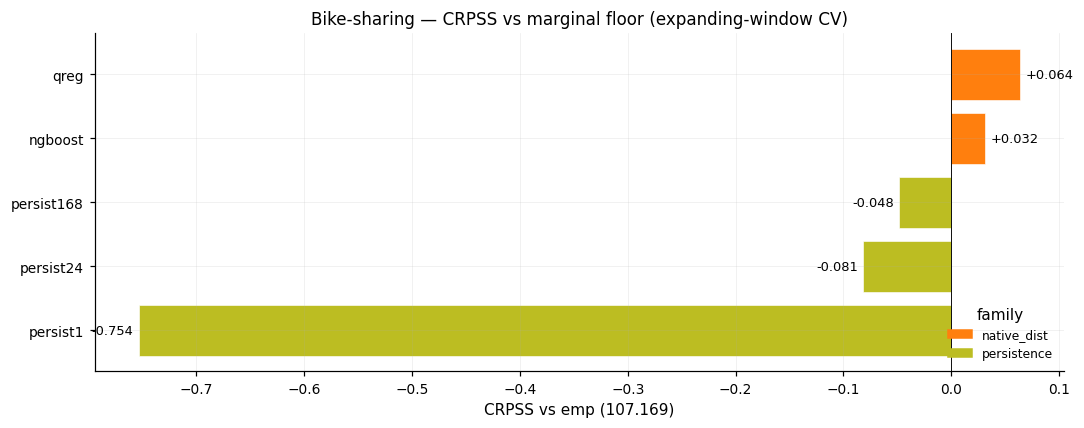

In [11]:
TS_MODEL = [
    Pipeline([EmpiricalDistribution()], name="emp"),
    Pipeline([Persistence(lag=1), GlobalResidual()], name="persist1"),
    Pipeline([Persistence(lag=24), GlobalResidual()], name="persist24"),
    Pipeline([Persistence(lag=168), GlobalResidual()], name="persist168"),
    Pipeline([QuantileReg(n_estimators=150, learning_rate=0.05, random_seed=0)], name="qreg"),
    Pipeline([NGBoostNormal(n_estimators=150, random_seed=0)], name="ngboost"),
]
print("fitting bike-sharing pipeline …")
ts_result = WalkForward(
    cv="expanding-window", n_folds=4, embargo=24, refit_on_full=False,
).fit_predict(TS_MODEL, X_b, y_b, ids=ids_b, timestamps=ts_b)
ts_scores = ts_result.score(y_b, metrics=["crps", "log_score"])

base_ts = ts_scores["emp"]["crps"]
seas_ts = ts_scores["persist24"]["crps"]
print(f"\n{'model':<14}{'CRPS':>10}{'log_score':>12}{'vs emp':>10}{'vs P-24':>10}")
print("-" * 56)
for stage, m in sorted(ts_scores.items(), key=lambda kv: kv[1]["crps"]):
    print(f"{stage:<14}{m['crps']:>10.2f}{m['log_score']:>12.2f}"
          f"{1-m['crps']/base_ts:>+10.3f}{1-m['crps']/seas_ts:>+10.3f}")

# Family map for the time-series bar.
ts_fams = {
    "emp": "baseline", "persist1": "persistence", "persist24": "persistence",
    "persist168": "persistence", "qreg": "native_dist", "ngboost": "native_dist",
}
fig = leaderboard_bar(
    [(s, ts_scores[s]["crps"]) for s in ts_scores],
    baseline_name="emp", baseline_value=base_ts,
    skill_label="CRPSS",
    families=ts_fams,
    title="Bike-sharing — CRPSS vs marginal floor (expanding-window CV)",
)
plt.show()

## Putting the numbers in perspective

**California housing** (y in $100k, std ≈ $115k):
- `Empirical` ≈ 0.61 — the marginal-CDF floor (~½ y-std), textbook
  climatology baseline.
- Well-tuned `QuantileReg` ≈ **0.25**, CRPSS ≈ 0.59. Published
  probabilistic-forecasting benchmarks see QReg/NGBoost/QF in the
  0.20–0.27 CRPS range on the full 20k-row dataset.
- `MAE ≈ 0.35` ($35k) for LightGBM is in line with classical-ML
  benchmarks for this dataset.

**Bike-sharing** (y is hourly rental count, range 0–977):
- `Empirical` ≈ 110.
- `Persistence(24)` ≈ 130 — sometimes *worse* than Empirical because the
  seasonal baseline is volatile across week-to-week regime changes.
- A genuine model on raw features should reach ~80–90 CRPS on the
  full dataset (this notebook subsamples and uses a temperature-only
  ensemble for EMOS, so absolute numbers under-estimate).